# Predicción de costos de seguro (insurance.csv)

En este notebook construimos paso a paso un pipeline para predecir la columna `charges` (costo del seguro) usando varios modelos de regresión.

## 1. Importar librerías y cargar datos

En este paso importamos las librerías principales y cargamos el archivo `insurance.csv` en un DataFrame de pandas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Cargar el dataset
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. EDA rápido (exploración de datos)

Revisamos dimensiones, tipos de datos, valores faltantes y estadísticas descriptivas de las variables numéricas.

In [3]:
# 2.1 Forma del dataset
print('Shape:', df.shape)

# 2.2 Tipos de datos
print('Tipos de datos:')
print(df.dtypes)

# 2.3 Valores faltantes
print('Valores faltantes por columna:')
print(df.isna().sum())

# 2.4 Estadísticas de variables numéricas
df.describe()

Shape: (1338, 7)
Tipos de datos:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
Valores faltantes por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### 2.5 Distribución de la variable objetivo `charges`

Visualizamos la distribución de `charges` para entender su forma.

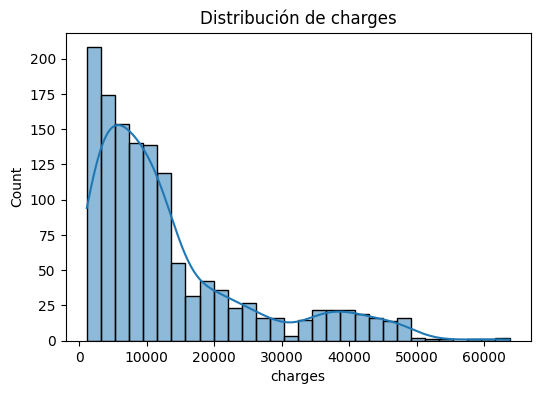

In [4]:
plt.figure(figsize=(6,4))
sns.histplot(df['charges'], kde=True)
plt.title('Distribución de charges')
plt.show()

### 2.6 Correlación numérica con `charges`

Calculamos la correlación de las variables numéricas con `charges`.

In [5]:
corr = df.corr(numeric_only=True)
corr['charges'].sort_values(ascending=False)

charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64

## 3. Preparación de datos (encoding y train/test split)

Definimos `X` e `y`, identificamos columnas numéricas y categóricas y armamos el `ColumnTransformer` con `OneHotEncoder`. Luego separamos en train/test.

In [6]:
# 3.1 Definir X e y
X = df.drop('charges', axis=1)
y = df['charges']

# 3.2 Columnas numéricas y categóricas
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

# 3.3 Preprocesador: OneHotEncoder para categóricas, 'passthrough' para numéricas
numeric_transformer = 'passthrough'
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 3.4 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((1070, 6), (268, 6))

## 4. Modelo 1: Regresión Lineal

Entrenamos un modelo de Regresión Lineal múltiple como línea base.

In [7]:
# 4.1 Definir el pipeline de regresión lineal
linreg_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

# 4.2 Entrenar
linreg_model.fit(X_train, y_train)

# 4.3 Predicciones y métricas en test
y_pred_lin = linreg_model.predict(X_test)
rmse_lin = mean_squared_error(y_test, y_pred_lin, squared=False)
r2_lin = r2_score(y_test, y_pred_lin)

print('Regresión Lineal - RMSE:', rmse_lin)
print('Regresión Lineal - R2:', r2_lin)

TypeError: got an unexpected keyword argument 'squared'

## 5. Modelo 2: Random Forest Regressor

Entrenamos un RandomForestRegressor para capturar relaciones no lineales.

In [ ]:
# 5.1 Definir el pipeline de Random Forest
rf_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# 5.2 Entrenar
rf_model.fit(X_train, y_train)

# 5.3 Predicciones y métricas en test
y_pred_rf = rf_model.predict(X_test)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
r2_rf = r2_score(y_test, y_pred_rf)

print('Random Forest - RMSE:', rmse_rf)
print('Random Forest - R2:', r2_rf)

## 6. Modelo 3: Gradient Boosting Regressor

Añadimos un GradientBoostingRegressor como tercer modelo.

In [ ]:
# 6.1 Definir el pipeline de Gradient Boosting
gb_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', GradientBoostingRegressor(
        random_state=42
    ))
])

# 6.2 Entrenar
gb_model.fit(X_train, y_train)

# 6.3 Predicciones y métricas en test
y_pred_gb = gb_model.predict(X_test)
rmse_gb = mean_squared_error(y_test, y_pred_gb, squared=False)
r2_gb = r2_score(y_test, y_pred_gb)

print('Gradient Boosting - RMSE:', rmse_gb)
print('Gradient Boosting - R2:', r2_gb)

## 7. Comparación de modelos

Comparamos las métricas principales (RMSE y R²) de cada modelo en test.

In [ ]:
results = pd.DataFrame({
    'modelo': ['Regresión Lineal', 'Random Forest', 'Gradient Boosting'],
    'RMSE_test': [rmse_lin, rmse_rf, rmse_gb],
    'R2_test': [r2_lin, r2_rf, r2_gb]
})
results

## 8. Validación cruzada (Random Forest)

Usamos validación cruzada para estimar de forma más robusta el desempeño del Random Forest en todo el dataset.

In [ ]:
# 8.1 Pipeline completo para validación cruzada
rf_cv_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# 8.2 Validación cruzada con 5 folds
rmse_scores = cross_val_score(
    rf_cv_model, X, y,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

print('RMSE por fold:', -rmse_scores)
print('RMSE promedio:', -rmse_scores.mean())
print('RMSE std:', rmse_scores.std())

## 9. Importancia de variables (Random Forest)

Calculamos la importancia de cada variable en el Random Forest para interpretar el modelo.

In [ ]:
# 9.1 Ajustar un RF sobre todo el conjunto de entrenamiento
rf_model_full = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])
rf_model_full.fit(X_train, y_train)

# 9.2 Recuperar nombres de features después del preprocesamiento
ohe = rf_model_full.named_steps['preprocess'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features)

feature_names = numeric_features + list(cat_feature_names)
importances = rf_model_full.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

feat_imp.head(15)